# Lab 04 - Problema 1  
## Árbol de expansión mínima como problema de búsqueda



## 1. Formulación como problema de búsqueda

Se tiene un grafo con varios nodos y conexiones, y cada conexión posee un peso o costo.

### Espacio de configuraciones

Las posibles soluciones son todas las formas de elegir conexiones para:

- unir todos los nodos,
- evitar ciclos,
- y usar solo las conexiones necesarias.

En otras palabras, se busca formar un árbol que conecte todo el grafo.

También pueden existir configuraciones parciales, es decir, conjuntos de conexiones que todavía no unen todo el grafo, pero que van en buen camino y no forman ciclos.

### Tamaño del espacio de búsqueda

La cantidad de posibles soluciones depende de cómo esté construido el grafo.

Si el grafo tiene muchas conexiones, entonces habrá más maneras de formar un árbol generador.

### Descripción de las configuraciones

Cada configuración puede representarse como una lista de conexiones elegidas hasta el momento.

Es decir, en cada paso se van agregando aristas válidas, siempre cuidando que no formen ciclos.

### Función de costo

El costo de una solución se obtiene sumando los pesos de todas las conexiones seleccionadas.

### Objetivo

El objetivo es encontrar la combinación de conexiones que logre unir todos los nodos con el menor costo total posible.

### Componentes de búsqueda

- **Estado inicial:** no se ha elegido ninguna conexión.
- **Acción:** agregar una conexión válida.
- **Restricción:** no formar ciclos.
- **Meta:** conectar todos los nodos usando solo las conexiones necesarias.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Grafo pequeño de ejemplo

Para que el árbol de búsqueda se vea claro, se usará un grafo pequeño de 4 nodos.

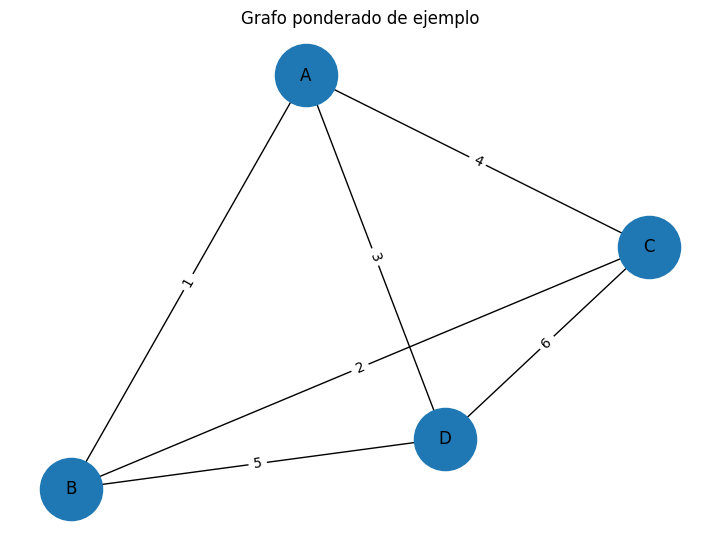

In [2]:
# Grafo de ejemplo
vertices = ["A", "B", "C", "D"]
weighted_edges = [
    ("A", "B", 1),
    ("A", "C", 4),
    ("A", "D", 3),
    ("B", "C", 2),
    ("B", "D", 5),
    ("C", "D", 6),
]

G = nx.Graph()
G.add_weighted_edges_from(weighted_edges)

pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(7, 5))
nx.draw(G, pos, with_labels=True, node_size=2000)
edge_labels = {(u, v): w for u, v, w in weighted_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Grafo ponderado de ejemplo")
plt.axis("off")
plt.show()

## 3. Árbol de búsqueda



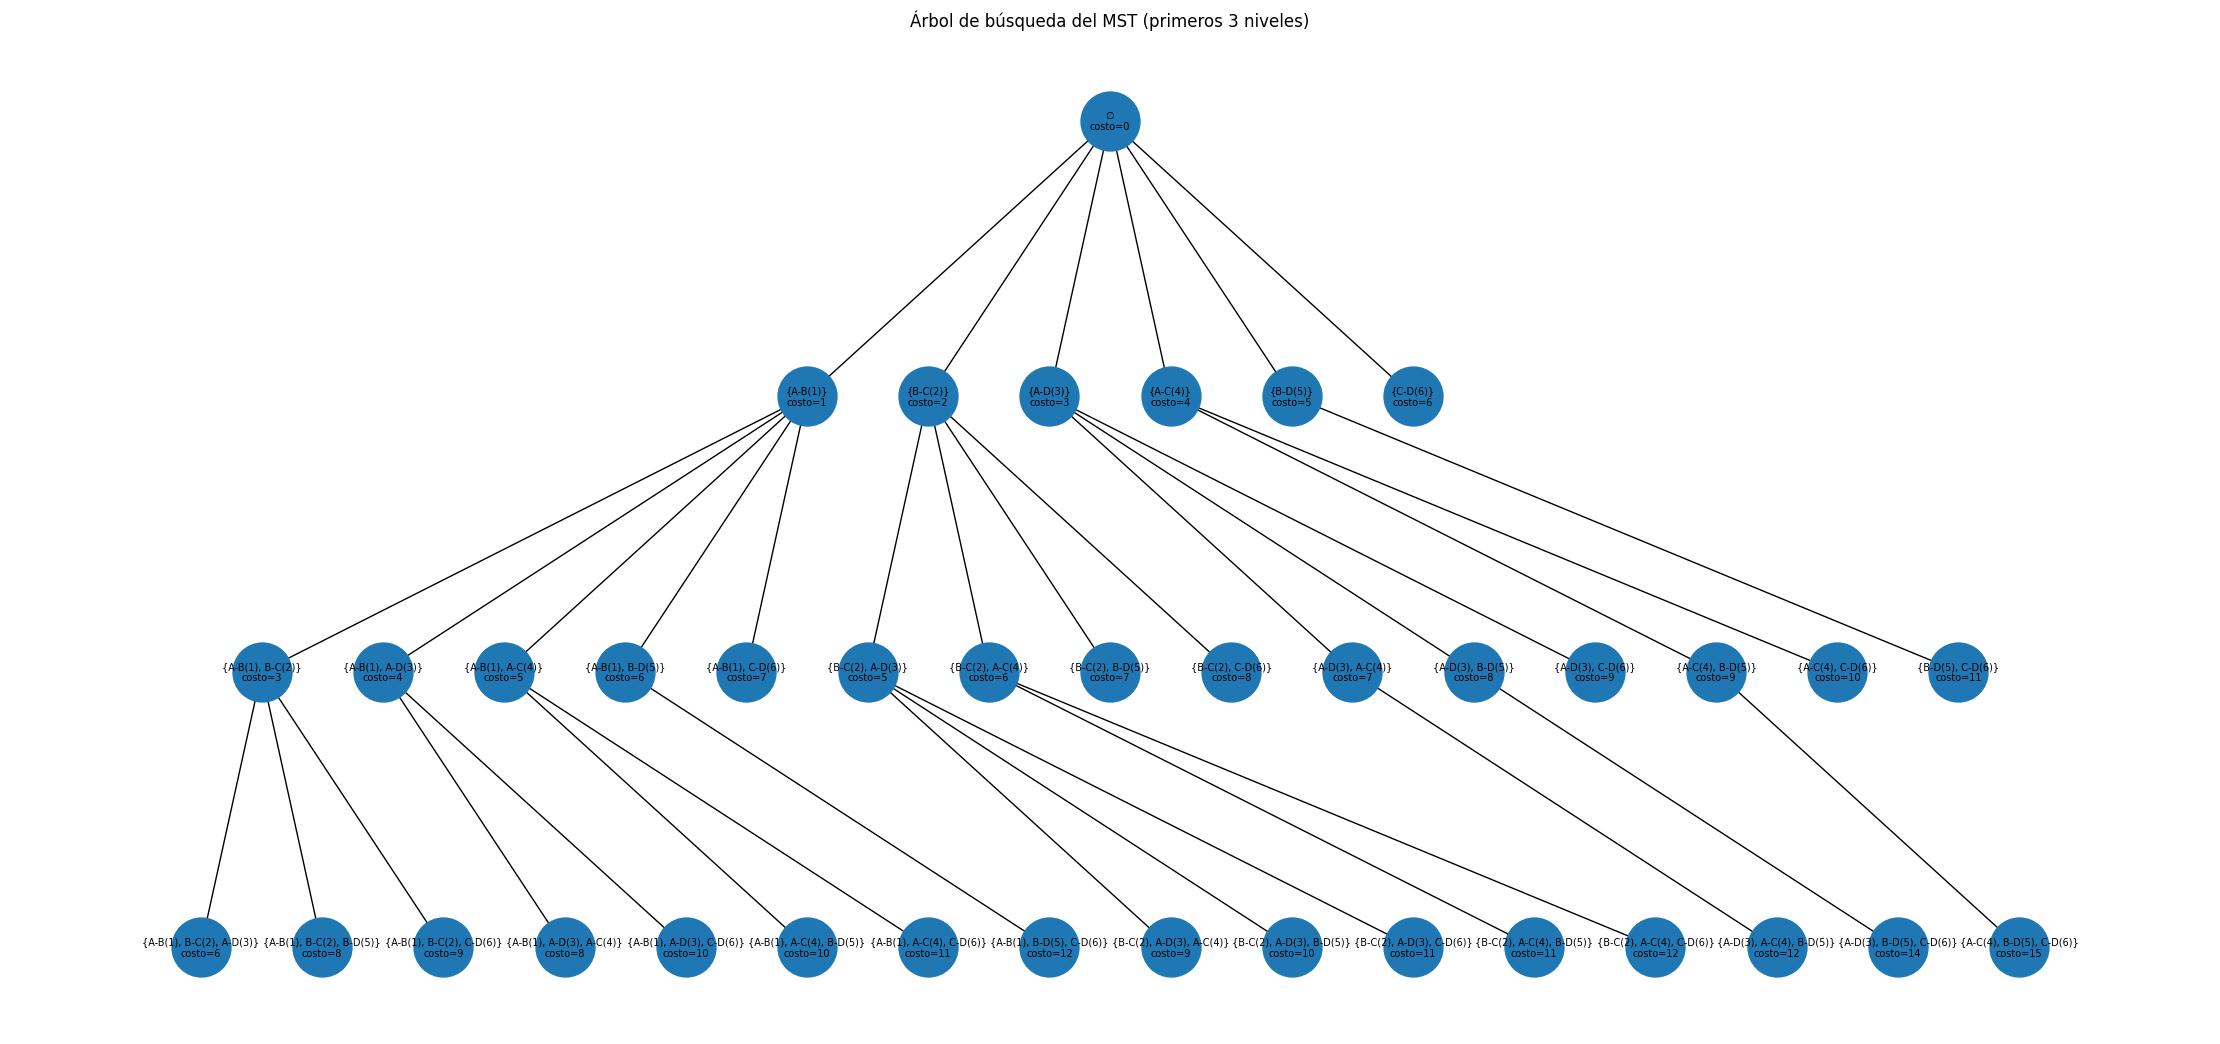

In [3]:
def edge_label(edge):
    u, v, w = edge
    return f"{u}-{v}({w})"

def forest_from_edges(vertices, edges):
    H = nx.Graph()
    H.add_nodes_from(vertices)
    H.add_weighted_edges_from(edges)
    return H

def is_acyclic(vertices, edges):
    H = forest_from_edges(vertices, edges)
    return nx.is_forest(H)

def state_cost(edges):
    return sum(w for _, _, w in edges)

weighted_edges_sorted = sorted(weighted_edges, key=lambda e: (e[2], e[0], e[1]))

def build_mst_search_tree(vertices, edges, max_depth=3):
    T = nx.DiGraph()
    root = tuple()
    T.add_node(root, level=0, label="∅\ncosto=0")

    def expand(state, start_idx, depth):
        if depth == max_depth:
            return

        for idx in range(start_idx, len(edges)):
            edge = edges[idx]
            new_state = tuple(list(state) + [edge])

            if is_acyclic(vertices, new_state):
                if new_state not in T:
                    lbl_edges = ", ".join(edge_label(e) for e in new_state)
                    T.add_node(
                        new_state,
                        level=len(new_state),
                        label=f"{{{lbl_edges}}}\ncosto={state_cost(new_state)}",
                    )

                T.add_edge(state, new_state)
                expand(new_state, idx + 1, depth + 1)

    expand(root, 0, 0)
    return T

search_tree = build_mst_search_tree(vertices, weighted_edges_sorted, max_depth=3)

def layered_positions(G):
    levels = {}
    for node, data in G.nodes(data=True):
        lvl = data["level"]
        levels.setdefault(lvl, []).append(node)

    pos = {}
    for lvl, nodes in levels.items():
        width = len(nodes)
        for i, node in enumerate(nodes):
            x = i - (width - 1) / 2
            y = -lvl
            pos[node] = (x, y)
    return pos

pos_tree = layered_positions(search_tree)
labels_tree = nx.get_node_attributes(search_tree, "label")

plt.figure(figsize=(22, 10))
nx.draw(search_tree, pos_tree, with_labels=False, node_size=1800, arrows=False)
nx.draw_networkx_labels(search_tree, pos_tree, labels=labels_tree, font_size=7)
plt.title("Árbol de búsqueda del MST (primeros 3 niveles)")
plt.axis("off")
plt.show()

## 4. Verificación del MST óptimo en el ejemplo


Aristas del MST:
A - B  peso = 1
A - D  peso = 3
B - C  peso = 2

Costo total del MST = 6


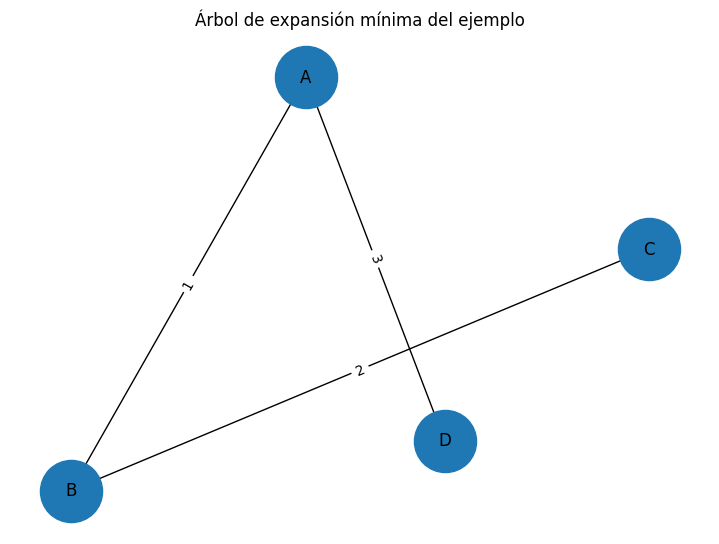

In [4]:
mst = nx.minimum_spanning_tree(G, algorithm="kruskal")

mst_edges = list(mst.edges(data=True))
mst_cost = sum(data["weight"] for _, _, data in mst_edges)

print("Aristas del MST:")
for u, v, data in mst_edges:
    print(f"{u} - {v}  peso = {data['weight']}")

print(f"\nCosto total del MST = {mst_cost}")

plt.figure(figsize=(7, 5))
nx.draw(mst, pos, with_labels=True, node_size=2000)
edge_labels_mst = {(u, v): data["weight"] for u, v, data in mst.edges(data=True)}
nx.draw_networkx_edge_labels(mst, pos, edge_labels=edge_labels_mst)
plt.title("Árbol de expansión mínima del ejemplo")
plt.axis("off")
plt.show()